In [2]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [3]:
#analyze the data
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

In [4]:
#feature engineering
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#import standard scaler
from sklearn.preprocessing import StandardScaler
#import simple imputer
from sklearn.impute import SimpleImputer
X=df.drop(['target'], axis=1)
y=df['target']

numeric_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

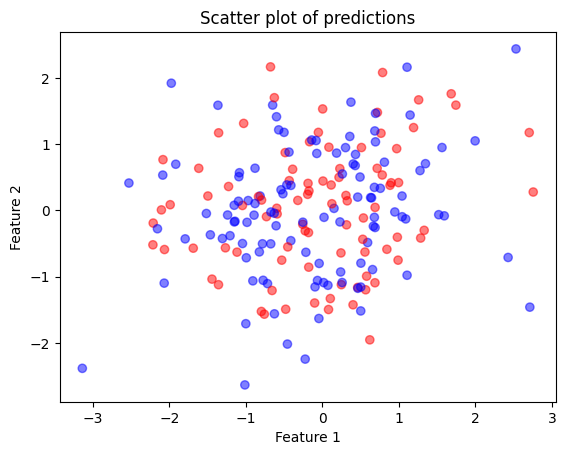

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(C=0.01)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='bwr', alpha=0.5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Scatter plot of predictions')
plt.show()

In [6]:
#evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.88
Precision: 0.8651685393258427
Recall: 0.8651685393258427
F1 Score: 0.8651685393258427


In [7]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {accuracy_train}")
print(f"Testing Accuracy: {accuracy_test}")

f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

print(f"Training F1 Score: {f1_train}")
print(f"Testing F1 Score: {f1_test}")

precision_train = precision_score(y_train, y_train_pred)
precision_test = precision_score(y_test, y_test_pred)
print(f"Training Precision: {precision_train}")
print(f"Testing Precision: {precision_test}")

recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_test_pred)
print(f"Training Recall: {recall_train}")
print(f"Testing Recall: {recall_test}")


Training Accuracy: 0.8575
Testing Accuracy: 0.88
Training F1 Score: 0.858560794044665
Testing F1 Score: 0.8651685393258427
Training Precision: 0.865
Testing Precision: 0.8651685393258427
Training Recall: 0.8522167487684729
Testing Recall: 0.8651685393258427


In [8]:
#now experiment with different regularization parameter (c) values for logistic regression.
c_values = [0.01, 0.1, 1, 10, 100]
for c in c_values:
    lr = LogisticRegression(C=c)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"C: {c}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")

C: 0.01
Accuracy: 0.88
Precision: 0.8651685393258427
Recall: 0.8651685393258427
F1 Score: 0.8651685393258427
C: 0.1
Accuracy: 0.875
Precision: 0.8636363636363636
Recall: 0.8539325842696629
F1 Score: 0.8587570621468926
C: 1
Accuracy: 0.875
Precision: 0.8636363636363636
Recall: 0.8539325842696629
F1 Score: 0.8587570621468926
C: 10
Accuracy: 0.875
Precision: 0.8636363636363636
Recall: 0.8539325842696629
F1 Score: 0.8587570621468926
C: 100
Accuracy: 0.875
Precision: 0.8636363636363636
Recall: 0.8539325842696629
F1 Score: 0.8587570621468926


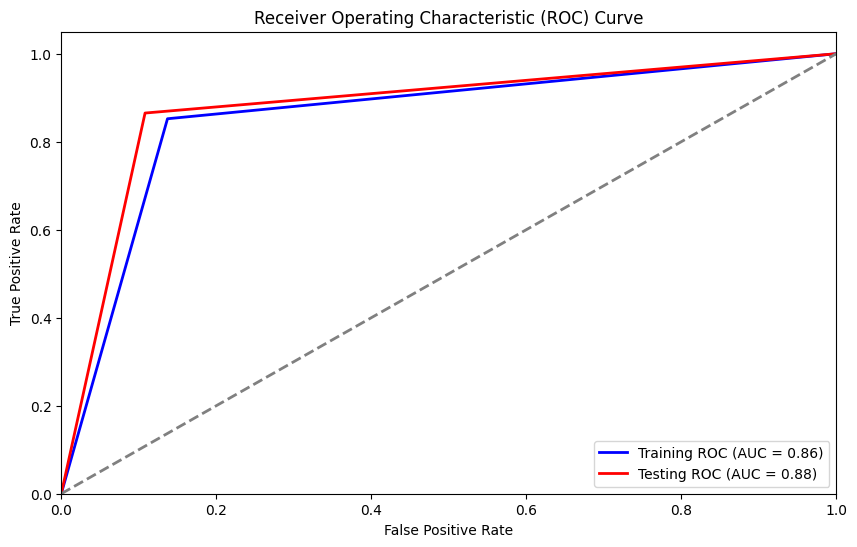

In [9]:
#plotting the ROC curve and analyzing model performance
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Training ROC (AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Testing ROC (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [12]:
#evaluate the confusion matrix
from sklearn.metrics import confusion_matrix
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix - Training Data:")
print(cm_train)
print("Confusion Matrix - Testing Data:")
print(cm_test)

Confusion Matrix - Training Data:
[[340  54]
 [ 60 346]]
Confusion Matrix - Testing Data:
[[99 12]
 [12 77]]
